# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|        Kadek Nathania Gavrila Astika      |  5054251050     |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
data = pd.read_csv("WineQT.csv")

# Menampilkan ukuran dataset
print("UKURAN DATASET")
print(f"Jumlah baris: {data.shape[0]}")
print(f"Jumlah kolom: {data.shape[1]}")

# Menampilkan 5 data pertama
print("\n5 DATA PERTAMA")
display(data.head())

# Menampilkan 5 data terakhir
print("\n5 DATA TERAKHIR")
display(data.tail())

# Menampilkan nama-nama kolom
print("\nNAMA KOLOM")
print(data.columns.tolist())

# Menampilkan informasi dataset
print("\nINFORMASI DATASET")
data.info()

# Menampilkan tipe data setiap kolom
print("\nTIPE DATA SETIAP KOLOM")
display(data.dtypes.to_frame(name="Tipe Data"))

# Mengecek jumlah nilai yang hilang
print("\nNILAI YANG HILANG")
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_summary = pd.DataFrame({
    "Jumlah Missing": missing_values,
    "Persentase Missing (%)": missing_percentage
})

display(missing_summary)

# Menampilkan jumlah nilai unik setiap kolom
print("\nJUMLAH NILAI UNIK")
unique_values = data.nunique()
display(unique_values.to_frame(name="Jumlah Nilai Unik"))

# Mengecek jumlah baris duplikat
print("\nDATA DUPLIKAT")
duplicate_count = data.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

# Statistik deskriptif untuk variabel numerik
print("\nSTATISTIK DESKRIPTIF")
display(data.describe().T)

UKURAN DATASET
Jumlah baris: 1143
Jumlah kolom: 13

5 DATA PERTAMA


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



5 DATA TERAKHIR


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597



NAMA KOLOM
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quali

...

,Jumlah Missing,Persentase Missing (%)
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0



JUMLAH NILAI UNIK


,Jumlah Nilai Unik
fixed acidity,91
volatile acidity,135
citric acid,77
residual sugar,80
chlorides,131
free sulfur dioxide,53
total sulfur dioxide,138
density,388
pH,87
sulphates,89



DATA DUPLIKAT
Jumlah baris duplikat: 0

STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


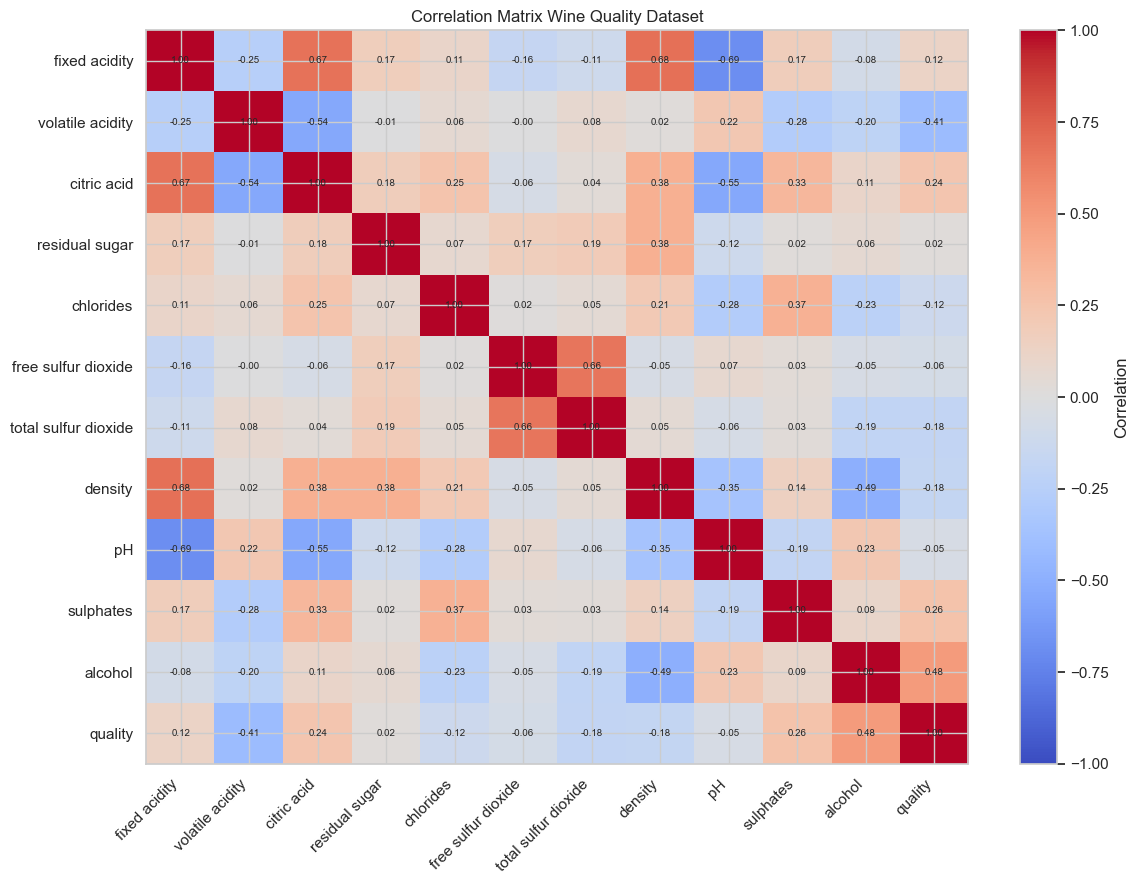

In [4]:
# Tampilkan Korelasi Matrix
corr_data = data.drop(columns=["Id"])
corr_matrix = corr_data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr_matrix, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix Wine Quality Dataset")
plt.tight_layout()
plt.show()

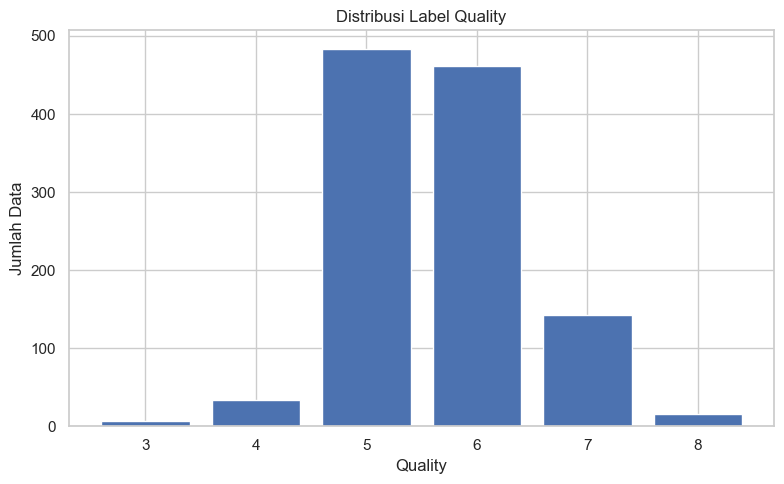

Distribusi label:


quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

In [5]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
counts = data["quality"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Distribusi Label Quality")
plt.xlabel("Quality")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

print("Distribusi label:")
display(counts)

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

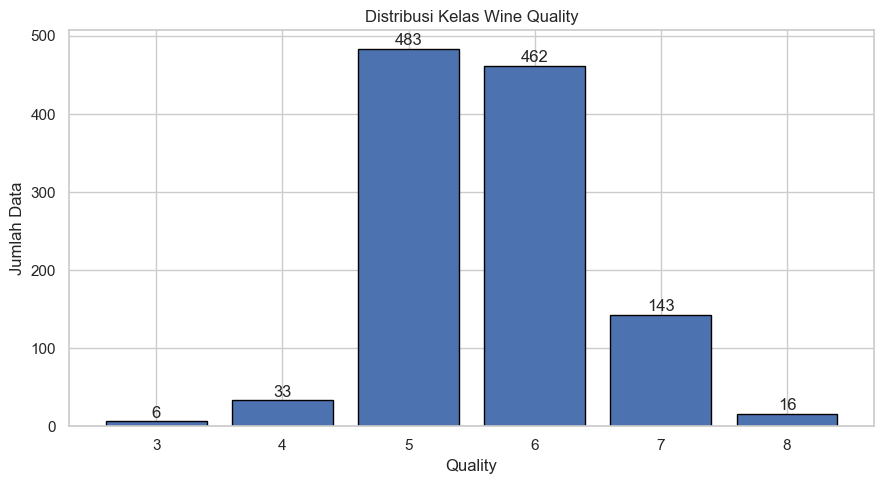

,jumlah data
quality,
3,6
4,33
5,483
6,462
7,143
8,16


In [6]:
# Visualisasi 1: Distribusi label quality dengan bar chart
counts = data["quality"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
bars = plt.bar(counts.index.astype(str), counts.values, edgecolor="black")
plt.title("Distribusi Kelas Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Jumlah Data")

for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(counts.values) * 0.01,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

display(counts.rename("jumlah data").to_frame())

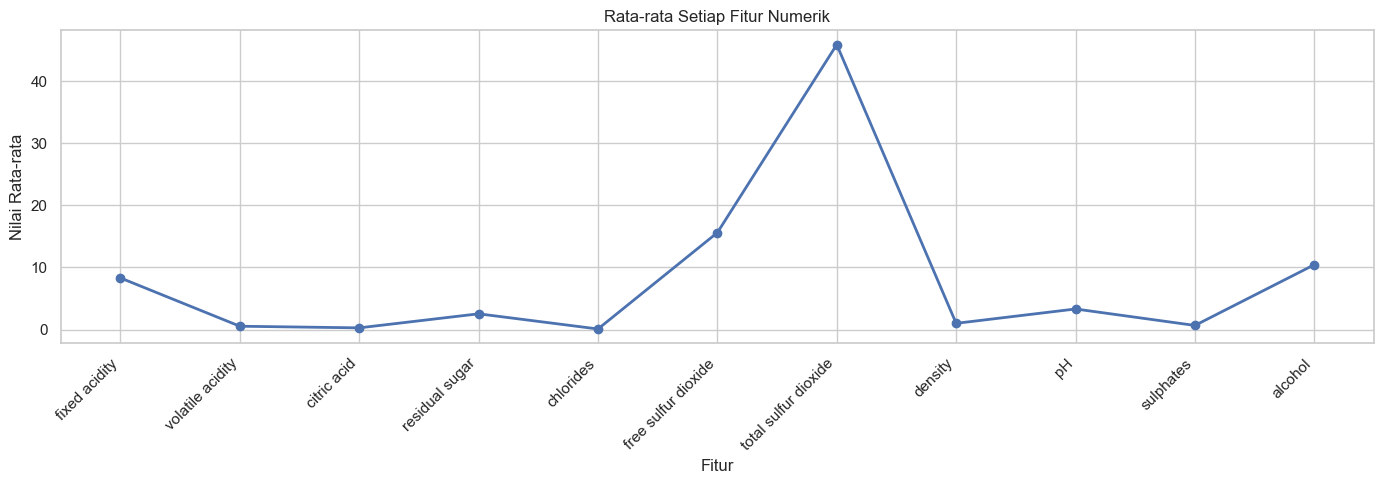

In [8]:
# Visualisasi 2: Line plot rata-rata setiap fitur numerik
# Line plot digunakan untuk melihat perbedaan skala rata-rata antar fitur.
feature_cols = [c for c in data.columns if c not in ["Id", "quality"]]
feature_means = data[feature_cols].mean()

plt.figure(figsize=(14, 5))
plt.plot(
    feature_means.index,
    feature_means.values,
    marker="o",
    linewidth=2
)
plt.title("Rata-rata Setiap Fitur Numerik")
plt.xlabel("Fitur")
plt.ylabel("Nilai Rata-rata")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


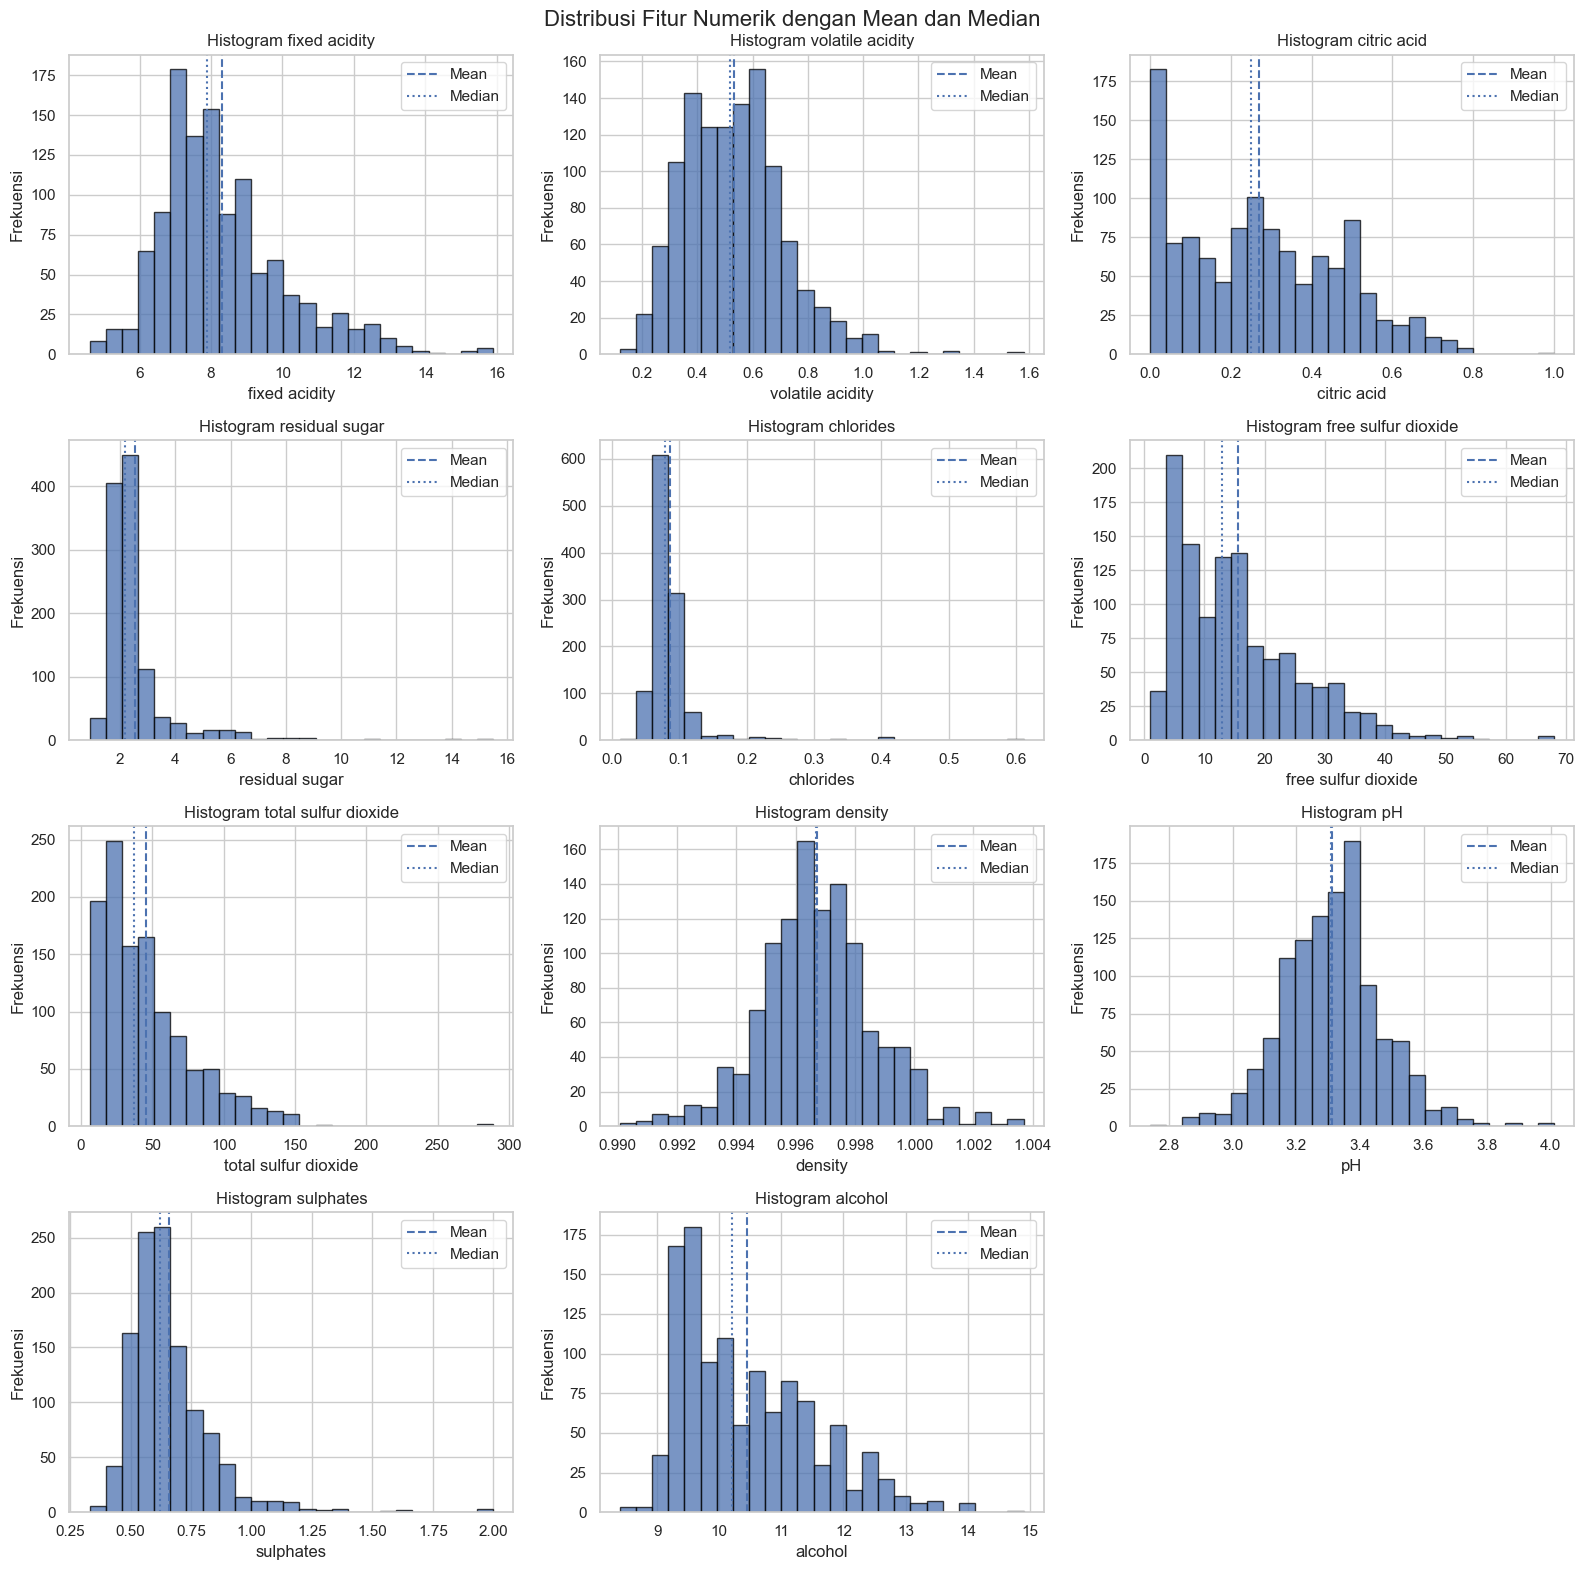

In [9]:
# Visualisasi 3: Histogram seluruh fitur numerik
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(16, 4 * n_rows)
)
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, feature_cols):
    ax.hist(data[col], bins=25, edgecolor="black", alpha=0.75)
    ax.axvline(data[col].mean(), linestyle="--", linewidth=1.5, label="Mean")
    ax.axvline(data[col].median(), linestyle=":", linewidth=1.5, label="Median")
    ax.set_title(f"Histogram {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frekuensi")
    ax.legend()

for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.suptitle("Distribusi Fitur Numerik dengan Mean dan Median", fontsize=16)
plt.tight_layout()
plt.show()


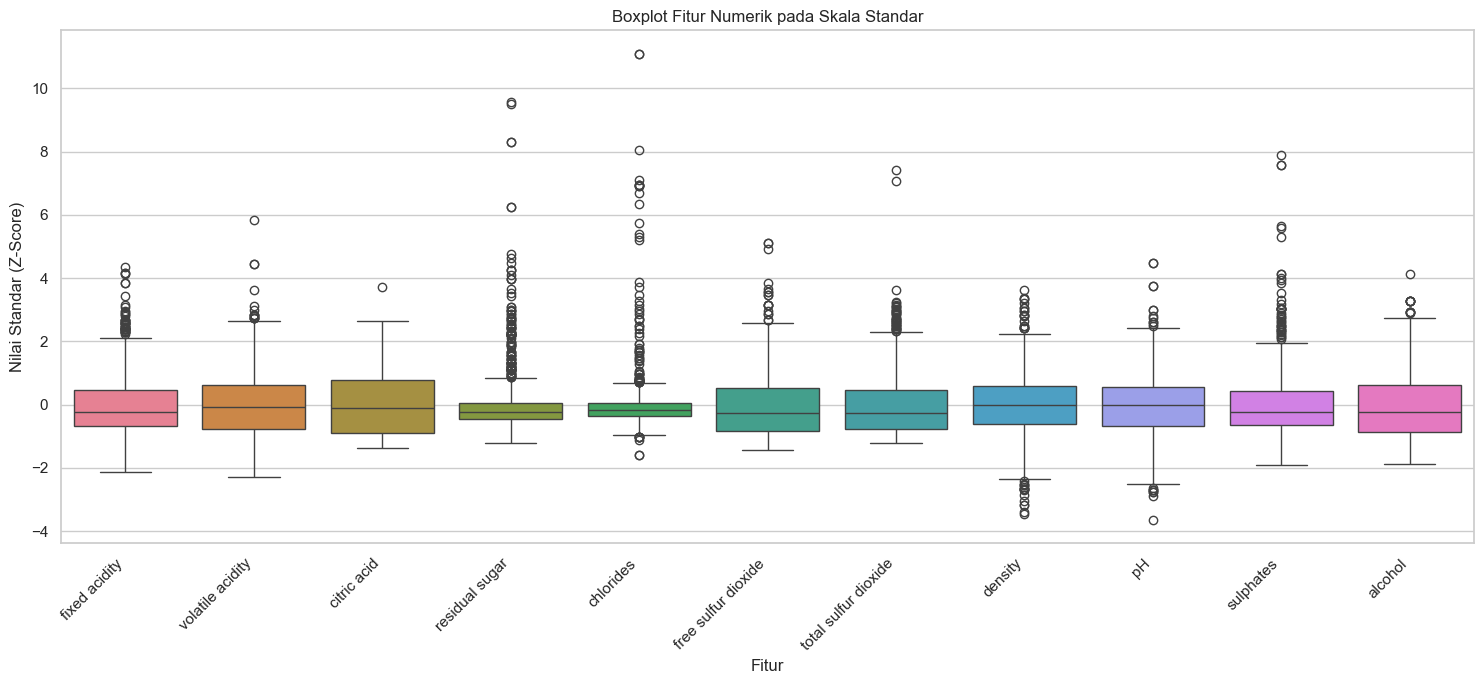

In [10]:
# Visualisasi 4: Boxplot seluruh fitur setelah normalisasi visual
# Setiap fitur dinormalisasi hanya untuk keperluan visualisasi agar skala dapat dibandingkan.
visual_scaled = pd.DataFrame(
    StandardScaler().fit_transform(data[feature_cols]),
    columns=feature_cols
)

plt.figure(figsize=(15, 7))
sns.boxplot(data=visual_scaled)
plt.title("Boxplot Fitur Numerik pada Skala Standar")
plt.xlabel("Fitur")
plt.ylabel("Nilai Standar (Z-Score)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Empat fitur dengan korelasi absolut terbesar terhadap quality:
['alcohol', 'volatile acidity', 'sulphates', 'citric acid']


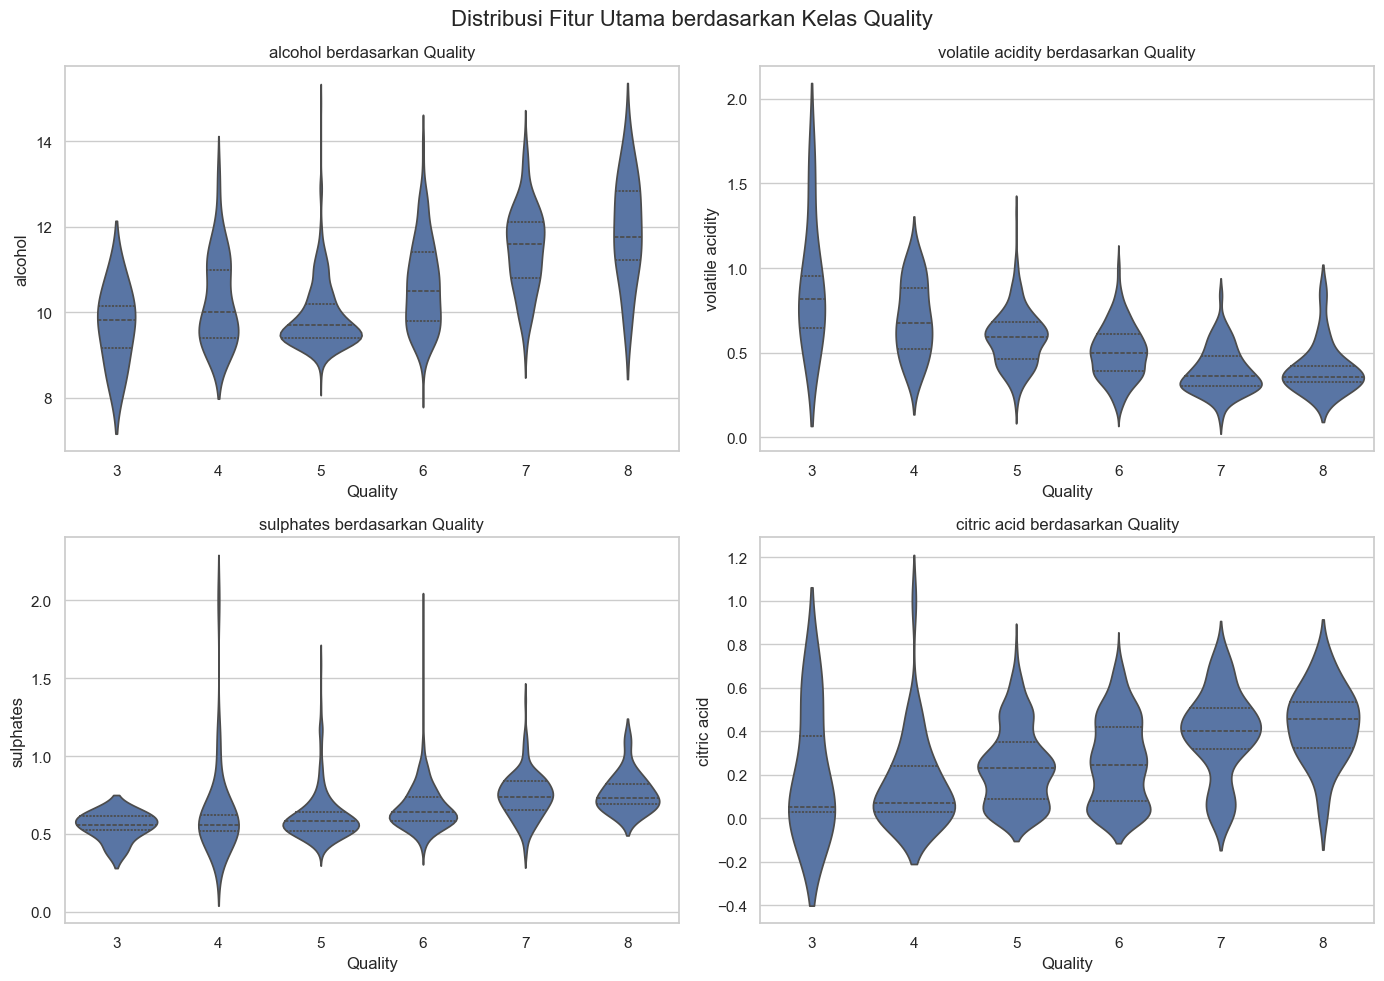

In [ ]:
# Visualisasi 5: Distribusi fitur utama berdasarkan quality dengan violin plot
target_corr = (
    data.drop(columns="Id")
        .corr(numeric_only=True)["quality"]
        .drop("quality")
        .sort_values(key=np.abs, ascending=False)
)

top_features = target_corr.head(4).index.tolist()
print("Empat fitur dengan korelasi absolut terbesar terhadap quality:")
print(top_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    sns.violinplot(
        data=data,
        x="quality",
        y=col,
        inner="quartile",
        ax=ax
    )
    ax.set_title(f"{col} berdasarkan Quality")
    ax.set_xlabel("Quality")
    ax.set_ylabel(col)

plt.suptitle("Distribusi Fitur Utama berdasarkan Kelas Quality", fontsize=16)
plt.tight_layout()
plt.show()


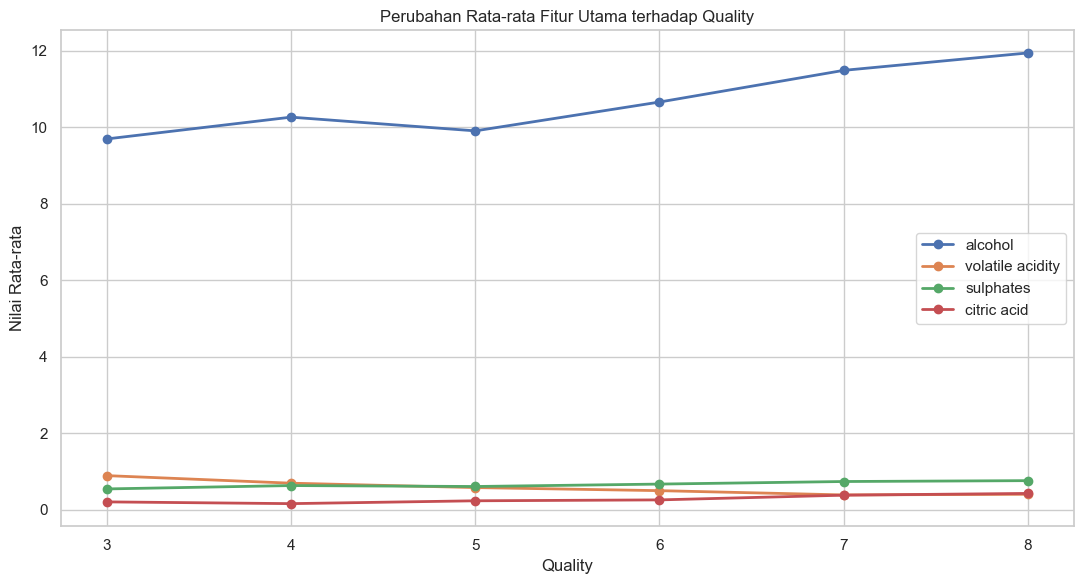

,alcohol,volatile acidity,sulphates,citric acid
quality,,,,
3,9.692,0.898,0.550,0.212
4,10.261,0.700,0.638,0.166
5,9.902,0.585,0.613,0.240
6,10.655,0.505,0.677,0.264
7,11.483,0.394,0.744,0.387
8,11.938,0.410,0.766,0.432


In [18]:
# Visualisasi 6: Rata-rata fitur utama pada setiap kelas quality
class_means = data.groupby("quality")[top_features].mean()

plt.figure(figsize=(11, 6))
for col in top_features:
    plt.plot(
        class_means.index,
        class_means[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("Perubahan Rata-rata Fitur Utama terhadap Quality")
plt.xlabel("Quality")
plt.ylabel("Nilai Rata-rata")
plt.xticks(class_means.index)
plt.legend()
plt.tight_layout()
plt.show()

display(class_means.round(3))


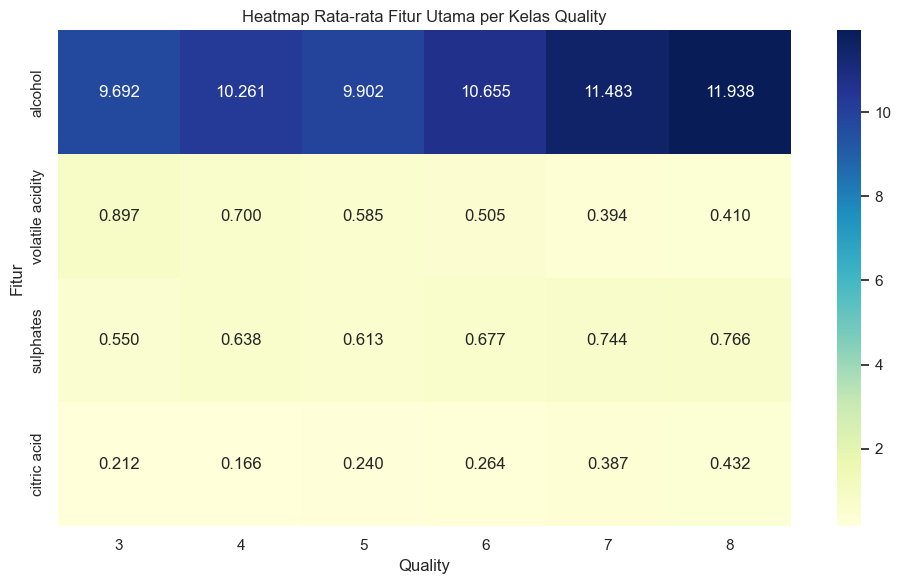

In [19]:
# Visualisasi 7: Heatmap rata-rata fitur utama per kelas
plt.figure(figsize=(10, 6))
sns.heatmap(
    class_means.T,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)
plt.title("Heatmap Rata-rata Fitur Utama per Kelas Quality")
plt.xlabel("Quality")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()


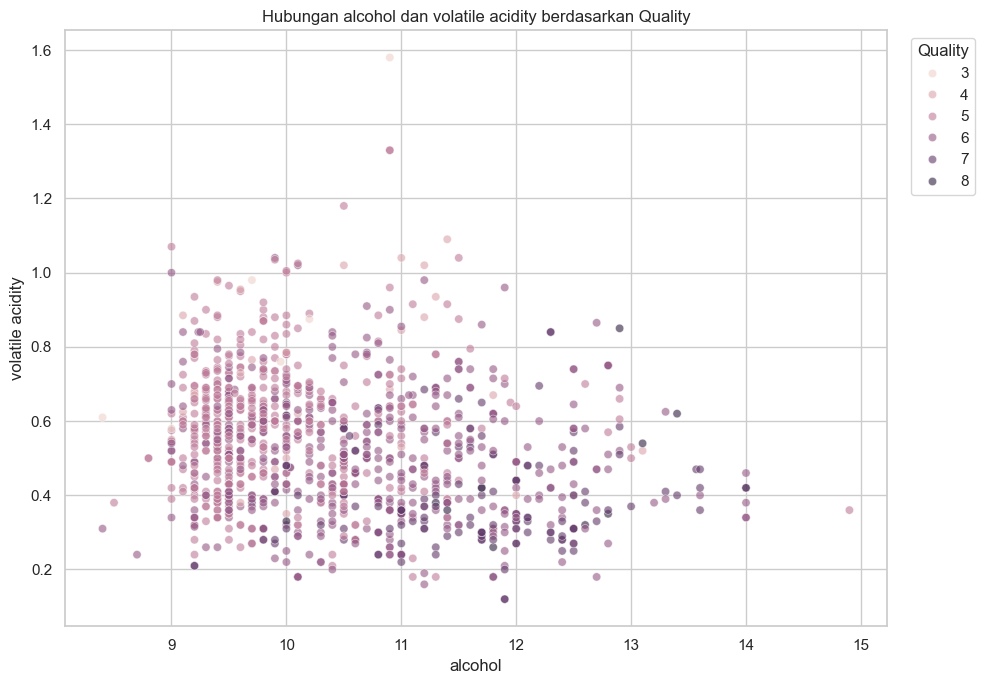

In [20]:
# Visualisasi 8: Scatter plot dua fitur teratas
x_feature, y_feature = top_features[0], top_features[1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=data,
    x=x_feature,
    y=y_feature,
    hue="quality",
    alpha=0.6
)
plt.title(f"Hubungan {x_feature} dan {y_feature} berdasarkan Quality")
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.legend(title="Quality", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


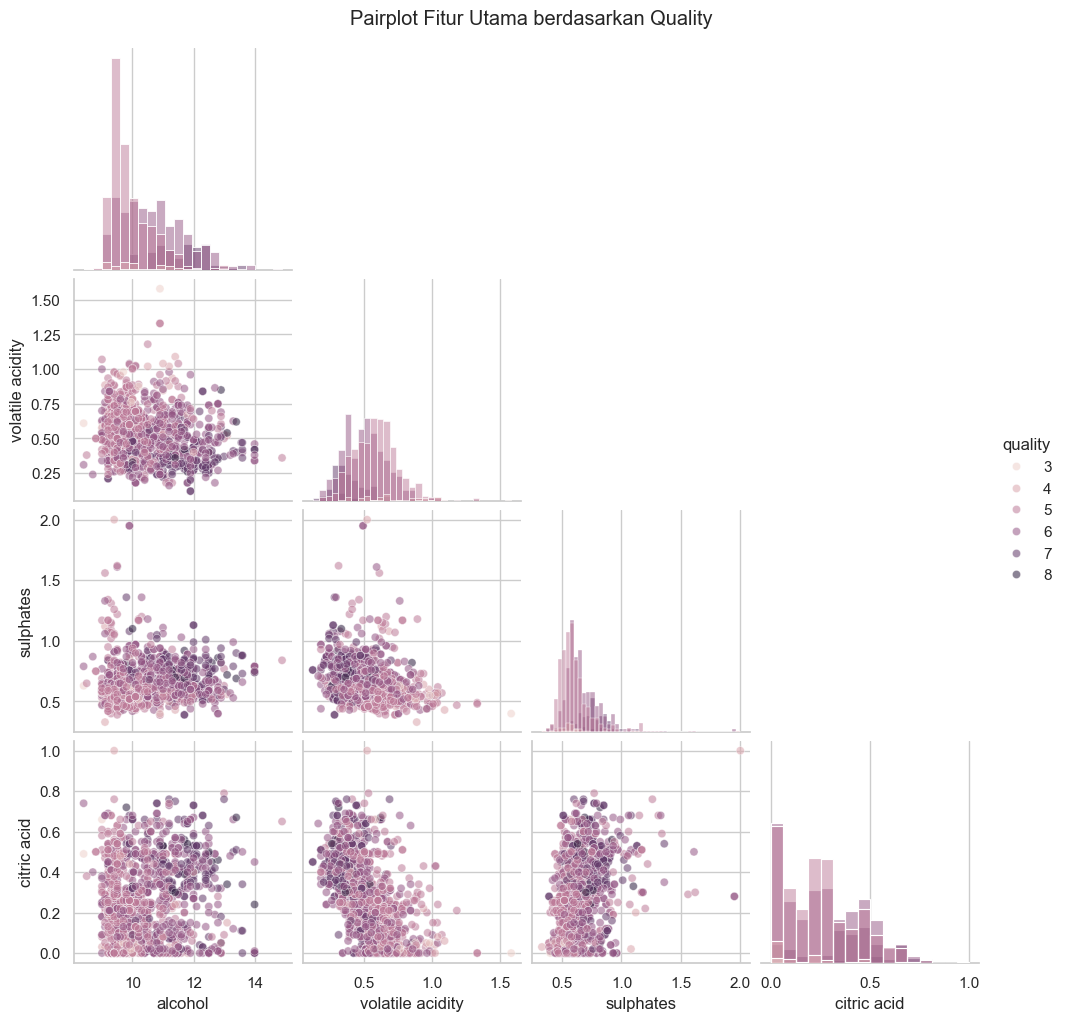

In [21]:
# Visualisasi 9: Pairplot fitur utama + quality
pairplot_cols = top_features + ["quality"]

sns.pairplot(
    data[pairplot_cols],
    hue="quality",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.55, "s": 35}
)
plt.suptitle("Pairplot Fitur Utama berdasarkan Quality", y=1.02)
plt.show()


# 2. Preprocessing




In [22]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
print("Missing value sebelum preprocessing:", data.isna().sum().sum())
print("Duplicate sebelum preprocessing:", data.duplicated().sum())

# Tidak ada missing value maupun duplicate, sehingga tidak diperlukan imputasi/drop.
data_clean = data.drop_duplicates().copy()

# Id hanya merupakan identifier dan tidak digunakan sebagai fitur.
X = data_clean.drop(columns=["quality", "Id"])
y = data_clean["quality"]

print("Ukuran data setelah preprocessing awal:", data_clean.shape)
print("Jumlah fitur yang digunakan:", X.shape[1])
print("Fitur:", list(X.columns))

Missing value sebelum preprocessing: 0
Duplicate sebelum preprocessing: 0
Ukuran data setelah preprocessing awal: (1143, 13)
Jumlah fitur yang digunakan: 11
Fitur: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


RINGKASAN OUTLIER SETIAP FITUR


,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase Outlier (%)
fixed acidity,7.100,9.100,2.000,4.100,12.100,44,3.850
volatile acidity,0.392,0.640,0.248,0.021,1.011,14,1.225
citric acid,0.090,0.420,0.330,-0.405,0.915,1,0.087
residual sugar,1.900,2.600,0.700,0.850,3.650,110,9.624
chlorides,0.070,0.090,0.020,0.040,0.120,77,6.737
free sulfur dioxide,7.000,21.000,14.000,-14.000,42.000,18,1.575
total sulfur dioxide,21.000,61.000,40.000,-39.000,121.000,40,3.500
density,0.996,0.998,0.002,0.992,1.001,36,3.150
pH,3.205,3.400,0.195,2.913,3.692,20,1.750
sulphates,0.550,0.730,0.180,0.280,1.000,43,3.762



FITUR YANG MEMILIKI OUTLIER


,Jumlah Outlier
residual sugar,110
chlorides,77
fixed acidity,44
sulphates,43
total sulfur dioxide,40
density,36
pH,20
free sulfur dioxide,18
volatile acidity,14
alcohol,12


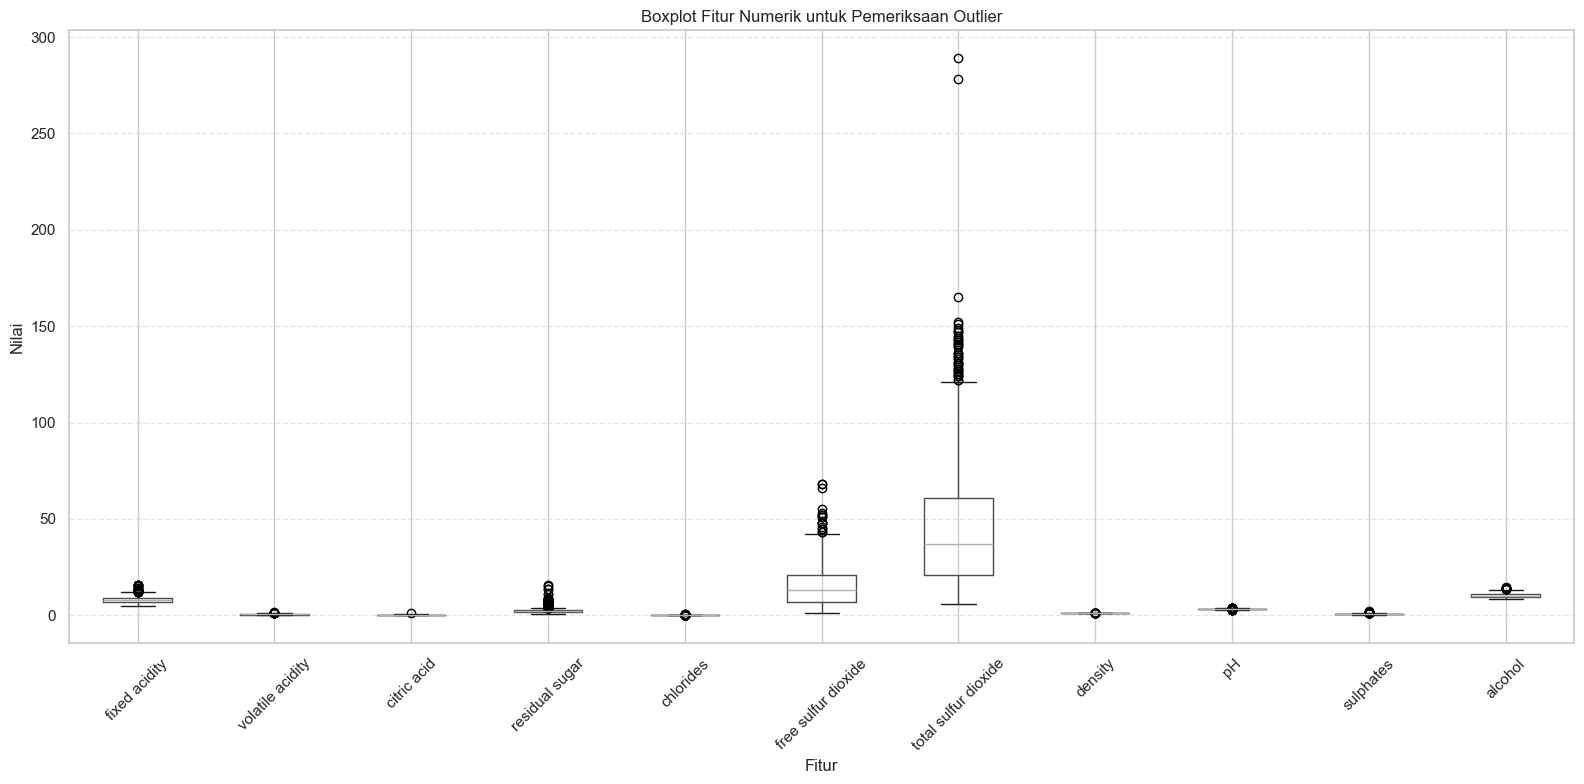

In [23]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
features = data.drop(columns=["Id", "quality"])

# Menghitung Q1, Q3, dan IQR
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menghitung jumlah outlier pada setiap fitur
outlier_count = ((features < lower_bound) | (features > upper_bound)).sum()

# Menghitung persentase outlier
outlier_percentage = (outlier_count / len(features)) * 100

# Membuat tabel ringkasan outlier
outlier_summary = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Batas Bawah": lower_bound,
    "Batas Atas": upper_bound,
    "Jumlah Outlier": outlier_count,
    "Persentase Outlier (%)": outlier_percentage
})

print("RINGKASAN OUTLIER SETIAP FITUR")
display(outlier_summary.round(3))

# Menampilkan fitur yang memiliki outlier
print("\nFITUR YANG MEMILIKI OUTLIER")
features_with_outlier = outlier_count[outlier_count > 0].sort_values(ascending=False)
display(features_with_outlier.to_frame(name="Jumlah Outlier"))

# Visualisasi boxplot untuk melihat outlier
plt.figure(figsize=(16, 8))
features.boxplot(rot=45)
plt.title("Boxplot Fitur Numerik untuk Pemeriksaan Outlier")
plt.ylabel("Nilai")
plt.xlabel("Fitur")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
# Memisahkan fitur dan target
X = data.drop(columns=["Id", "quality"])
y = data["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran data training:", X_train.shape)
print("Ukuran data testing:", X_test.shape)

# StandardScaler
standard_scaler = StandardScaler()
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

# MinMaxScaler sebagai pembanding
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

scaling_comparison = pd.DataFrame({
    "Metode": ["StandardScaler", "MinMaxScaler"],
    "Minimum X_train": [X_train_standard.min(), X_train_minmax.min()],
    "Maksimum X_train": [X_train_standard.max(), X_train_minmax.max()]
})

print("\nPerbandingan hasil scaling:")
display(scaling_comparison.round(3))

# StandardScaler digunakan untuk eksperimen utama KNN.
X_train_scaled = pd.DataFrame(
    X_train_standard,
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    X_test_standard,
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

Ukuran data training: (914, 11)
Ukuran data testing: (229, 11)

Perbandingan hasil scaling:


,Metode,Minimum X_train,Maksimum X_train
0,StandardScaler,-3.702,10.451
1,MinMaxScaler,0.000,1.000


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
819,-0.012101,0.388684,-0.109113,-0.264324,0.609897,-0.643427,-0.236286,-0.299229,-1.039511,-0.731171,-0.608473
357,1.248615,-1.626485,0.761211,-0.600511,-0.208555,-0.942939,-0.719059,0.454173,-0.649907,2.263064,0.330960
385,0.675563,-0.394993,1.119580,3.181593,-0.468065,-1.042777,-0.869926,1.082009,-0.649907,0.420458,0.518847
1057,-1.559342,0.500638,-1.235414,-0.852652,-0.148669,-0.942939,-0.990619,-0.916601,2.272119,-0.212938,-0.326643
161,0.331731,0.332708,1.170776,-0.432418,4.981632,1.153646,1.061167,-0.173662,-1.753784,5.487625,-0.890303


# 3. Eksperimen Model KNN


Train: 914 baris | Test: 229 baris

Distribusi quality pada data train:


quality
3      5
4     26
5    386
6    370
7    114
8     13
Name: count, dtype: int64


Distribusi quality pada data test:


quality
3     1
4     7
5    97
6    92
7    29
8     3
Name: count, dtype: int64


Perbandingan KNN dengan dan tanpa scaling:
Tanpa scaling : 0.4891
Dengan scaling: 0.5764
Selisih       : +0.0873

Hasil eksperimen KNN:


,k,metric,train_accuracy,test_accuracy
0,1,euclidean,1.0000,0.6507
1,3,euclidean,0.7593,0.6070
2,5,euclidean,0.6838,0.5764
3,7,euclidean,0.6630,0.5939
4,9,euclidean,0.6400,0.6201
5,1,manhattan,1.0000,0.6594
6,3,manhattan,0.7462,0.5677
7,5,manhattan,0.6915,0.5852
8,7,manhattan,0.6641,0.6114
9,9,manhattan,0.6477,0.6594



Hasil eksperimen berdasarkan test accuracy:


,k,metric,train_accuracy,test_accuracy
0,9,manhattan,0.6477,0.6594
1,1,manhattan,1.0000,0.6594
2,1,euclidean,1.0000,0.6507
3,9,euclidean,0.6400,0.6201
4,7,manhattan,0.6641,0.6114
5,3,euclidean,0.7593,0.6070
6,7,euclidean,0.6630,0.5939
7,5,manhattan,0.6915,0.5852
8,5,euclidean,0.6838,0.5764
9,3,manhattan,0.7462,0.5677



Model dengan test accuracy tertinggi: k=9, metric=manhattan, accuracy=0.6594


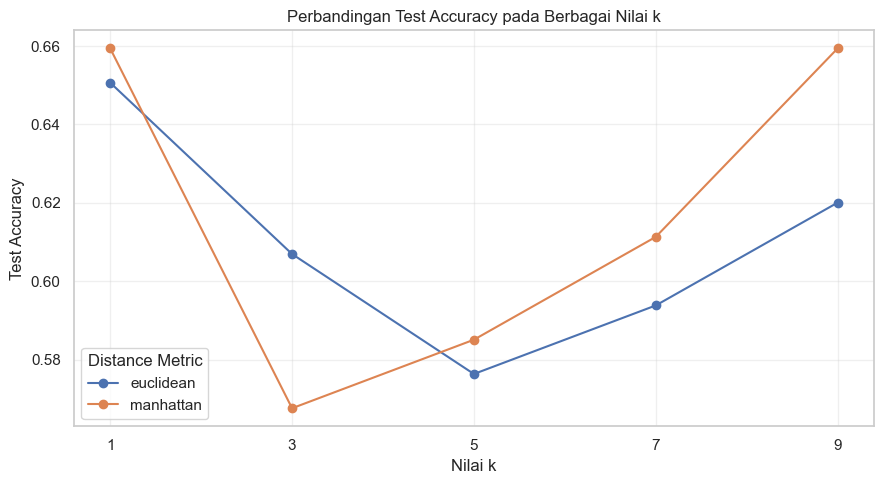

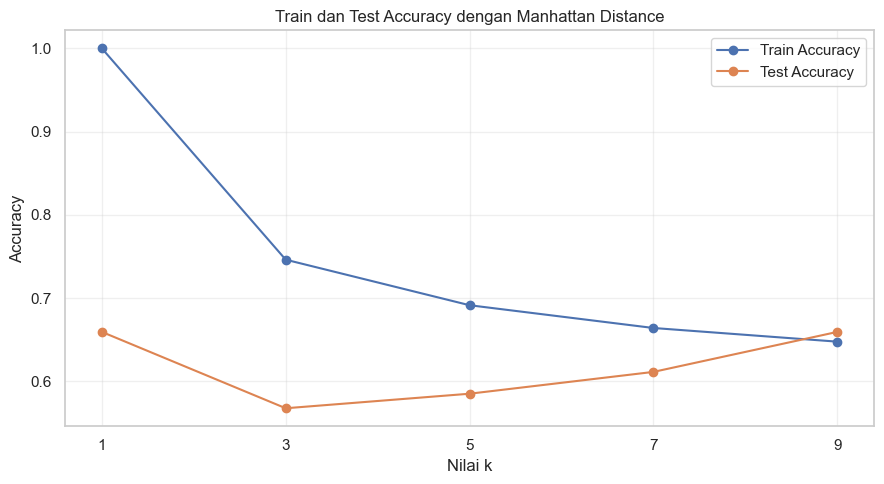

In [25]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
X = data.drop(columns=["Id", "quality"])
y = data["quality"]

# Membagi data menjadi 80% train dan 20% test
# stratify digunakan agar proporsi setiap kelas quality tetap terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} baris | Test: {X_test.shape[0]} baris")

# Melihat distribusi label pada train dan test
print("\nDistribusi quality pada data train:")
display(y_train.value_counts().sort_index())

print("\nDistribusi quality pada data test:")
display(y_test.value_counts().sort_index())


# Scaling data
# StandardScaler di-fit hanya pada data train untuk menghindari data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Membandingkan KNN tanpa scaling dan dengan scaling
# k=5 digunakan sebagai contoh untuk melihat pengaruh scaling
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)

pred_raw = knn_raw.predict(X_test)
acc_raw = accuracy_score(y_test, pred_raw)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, pred_scaled)

print("\nPerbandingan KNN dengan dan tanpa scaling:")
print(f"Tanpa scaling : {acc_raw:.4f}")
print(f"Dengan scaling: {acc_scaled:.4f}")
print(f"Selisih       : {acc_scaled - acc_raw:+.4f}")

# KNN menggunakan jarak untuk menentukan tetangga terdekat.
# Scaling diperlukan agar fitur dengan rentang nilai besar
# tidak mendominasi perhitungan jarak.


# Eksperimen beberapa nilai k dan distance metric
k_values = [1, 3, 5, 7, 9]
distance_metrics = ["euclidean", "manhattan"]

experiment_results = []
knn_models = {}

for metric in distance_metrics:
    for k in k_values:

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        knn.fit(X_train_scaled, y_train)

        train_pred = knn.predict(X_train_scaled)
        test_pred = knn.predict(X_test_scaled)

        train_accuracy = accuracy_score(y_train, train_pred)
        test_accuracy = accuracy_score(y_test, test_pred)

        experiment_results.append({
            "k": k,
            "metric": metric,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy
        })

        knn_models[(k, metric)] = knn


# Menampilkan hasil seluruh eksperimen
results_df = pd.DataFrame(experiment_results)

print("\nHasil eksperimen KNN:")
display(results_df.round(4))


# Mengurutkan hasil berdasarkan test accuracy
results_sorted = results_df.sort_values(
    "test_accuracy",
    ascending=False
).reset_index(drop=True)

print("\nHasil eksperimen berdasarkan test accuracy:")
display(results_sorted.round(4))


# Menentukan kombinasi k dan metric dengan test accuracy tertinggi
best_result = results_sorted.iloc[0]

best_k = int(best_result["k"])
best_metric = best_result["metric"]
best_accuracy = best_result["test_accuracy"]

print(
    f"\nModel dengan test accuracy tertinggi: "
    f"k={best_k}, metric={best_metric}, "
    f"accuracy={best_accuracy:.4f}"
)


# Visualisasi test accuracy untuk setiap nilai k
plt.figure(figsize=(9, 5))

for metric in distance_metrics:
    metric_result = results_df[
        results_df["metric"] == metric
    ].sort_values("k")

    plt.plot(
        metric_result["k"],
        metric_result["test_accuracy"],
        marker="o",
        label=metric
    )

plt.xlabel("Nilai k")
plt.ylabel("Test Accuracy")
plt.title("Perbandingan Test Accuracy pada Berbagai Nilai k")
plt.xticks(k_values)
plt.legend(title="Distance Metric")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Membandingkan train accuracy dan test accuracy
# untuk metric terbaik
best_metric_result = results_df[
    results_df["metric"] == best_metric
].sort_values("k")

plt.figure(figsize=(9, 5))

plt.plot(
    best_metric_result["k"],
    best_metric_result["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    best_metric_result["k"],
    best_metric_result["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Nilai k")
plt.ylabel("Accuracy")
plt.title(
    f"Train dan Test Accuracy dengan {best_metric.capitalize()} Distance"
)
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 4. Evaluasi Model


Model terbaik: k=9, metric=manhattan
Accuracy : 0.6594
Precision: 0.3061
Recall   : 0.3097
F1-Score : 0.3065

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.78      0.76        97
           6       0.63      0.70      0.66        92
           7       0.48      0.38      0.42        29
           8       0.00      0.00      0.00         3

    accuracy                           0.66       229
   macro avg       0.31      0.31      0.31       229
weighted avg       0.62      0.66      0.64       229



<Figure size 700x500 with 0 Axes>

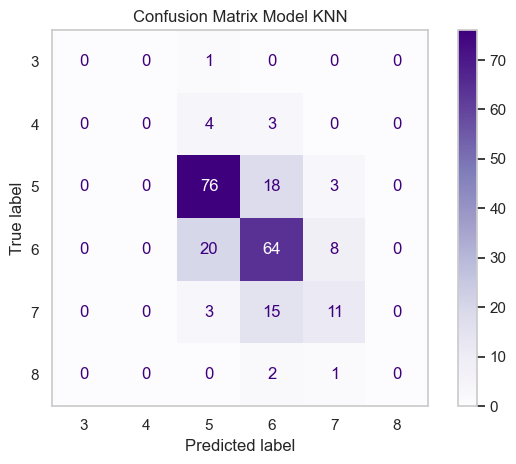

In [30]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

# Menggunakan model terbaik dari hasil eksperimen
best_model = knn_models[(best_k, best_metric)]

# Prediksi pada data test
y_pred = best_model.predict(X_test_scaled)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Model terbaik: k={best_k}, metric={best_metric}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Classification report untuk melihat performa setiap kelas
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

disp.plot(cmap="Purples", values_format="d")

plt.grid(False)
plt.title("Confusion Matrix Model KNN")
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

Hasil eksperimen menunjukkan bahwa model KNN terbaik diperoleh pada k = 9 dengan metrik Manhattan, dengan akurasi sebesar 65,94%. Meskipun akurasinya cukup baik, nilai precision, recall, dan F1-score macro masih rendah, yaitu sekitar 30%, yang menunjukkan bahwa performa model belum merata pada seluruh kelas. Model bekerja paling baik pada kelas 5 dan 6, sedangkan kelas 3, 4, dan 8 tidak berhasil diprediksi dengan benar, kemungkinan karena jumlah datanya jauh lebih sedikit. Dibandingkan eksperimen lainnya, kombinasi k=9 dan Manhattan dipilih sebagai model terbaik karena menghasilkan performa keseluruhan paling tinggi berdasarkan hasil pengujian.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Berdasarkan eksperimen, penggunaan scaling meningkatkan akurasi KNN dari 48,91% menjadi 57,64%, sehingga scaling terbukti membantu performa model. Dari seluruh kombinasi yang diuji, model terbaik adalah KNN dengan k=9 dan metrik Manhattan dengan test accuracy sebesar 65,94%, meskipun model k=1 dengan Manhattan memiliki akurasi test yang sama. Distribusi data yang tidak seimbang, terutama dominasi kelas 5 dan 6 serta sedikitnya data pada kelas 3, 4, dan 8, menyebabkan model kurang mampu mengenali kelas minoritas. Untuk eksperimen selanjutnya, disarankan menggunakan penanganan data tidak seimbang seperti oversampling/SMOTE, mencoba nilai k dan metrik jarak yang lebih beragam, serta membandingkan KNN dengan algoritma klasifikasi lain untuk mendapatkan performa yang lebih baik.